# Lotka Volterra (4 parameters) test case  

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from data_collection import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [2]:
# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [3]:
import itertools

# Define the intervals and number of points
num_points = 5  # Number of points in each linspace (adjust as needed)
# first_interval = np.linspace(2, 3.2, num_points)
# second_interval = np.linspace(0.6, 1.9, num_points)
# third_interval = np.linspace(0.6, 1.9, num_points)
# fourth_interval = np.linspace(0.8, 2.1, num_points)
first_interval = np.linspace(2.1, 3, num_points)
second_interval = np.linspace(0.9, 1.5, num_points)
third_interval = np.linspace(0.9, 1.5, num_points)
fourth_interval = np.linspace(1., 2.1, num_points)
# Generate all combinations using itertools.product
combinations = list(itertools.product(first_interval, second_interval, third_interval, fourth_interval))

# Convert the combinations to a numpy array
combinations_array = np.array(combinations)

# Shuffle the rows of the array
np.random.shuffle(combinations_array)

print(combinations_array)

[[3.    1.2   1.05  1.55 ]
 [3.    0.9   0.9   1.   ]
 [2.775 1.05  1.05  1.55 ]
 ...
 [3.    1.05  0.9   1.55 ]
 [2.325 0.9   0.9   1.   ]
 [2.55  0.9   1.35  1.   ]]


In [4]:
# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [5]:
solver_HF = System2()
solver_LF = System2()

num_params=4
params=combinations_array[0:10,:]

(t_HF,y_HF,mu_HF)=solver_HF.generate_dataset(T=7.0, params=params, h=0.01, fidelity='HF')
solver_HF.save_dataset('dataset_HF_4params.h5')

(t_LF,y_LF,mu_LF)=solver_LF.generate_dataset(T=7.0, params=params, h=0.04, fidelity='LF')   #0.04
solver_LF.save_dataset('dataset_LF_4params.h5')


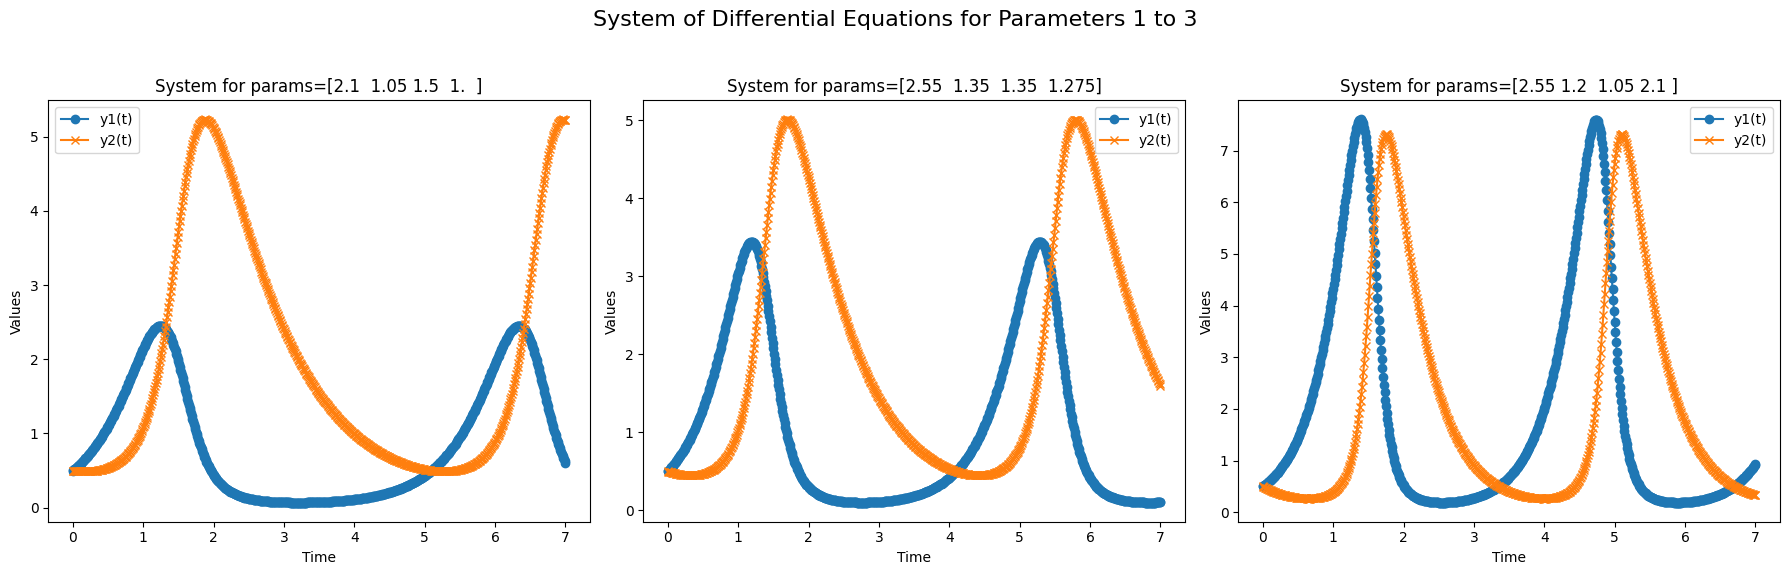

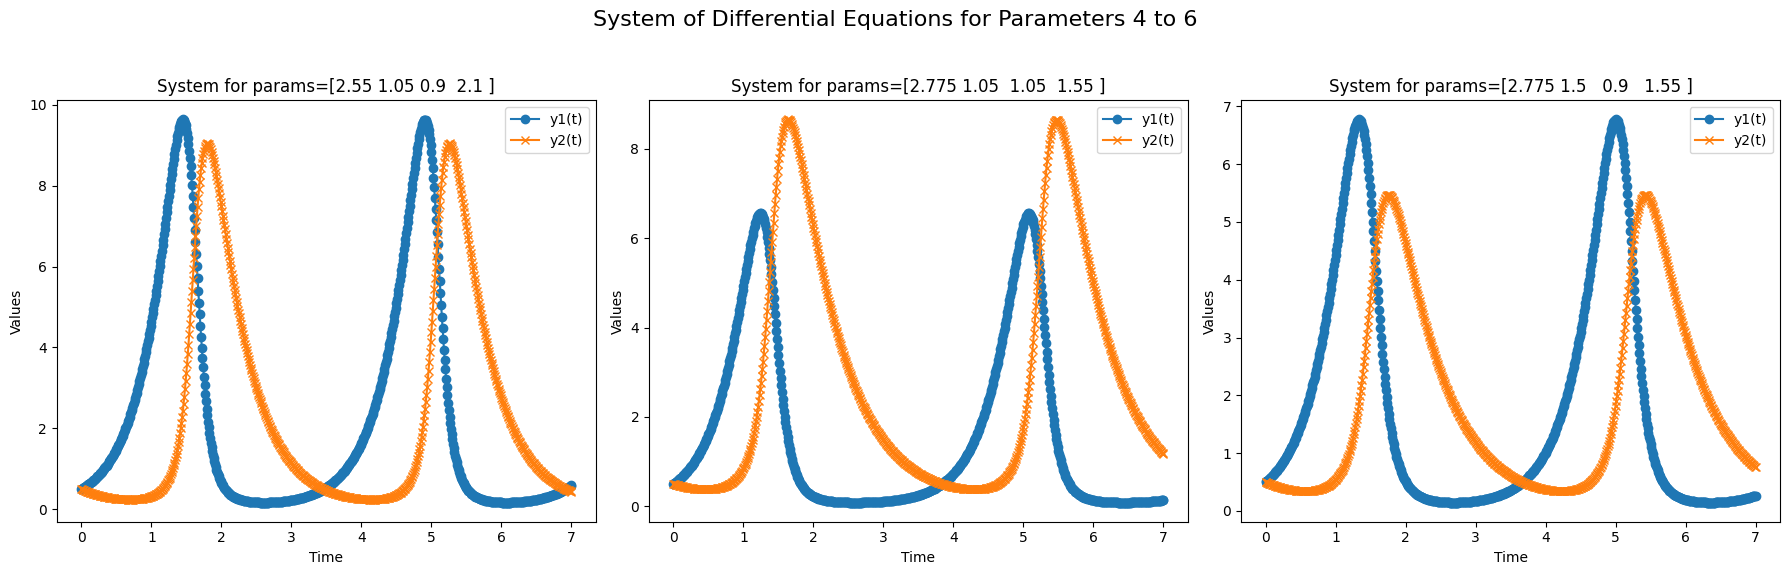

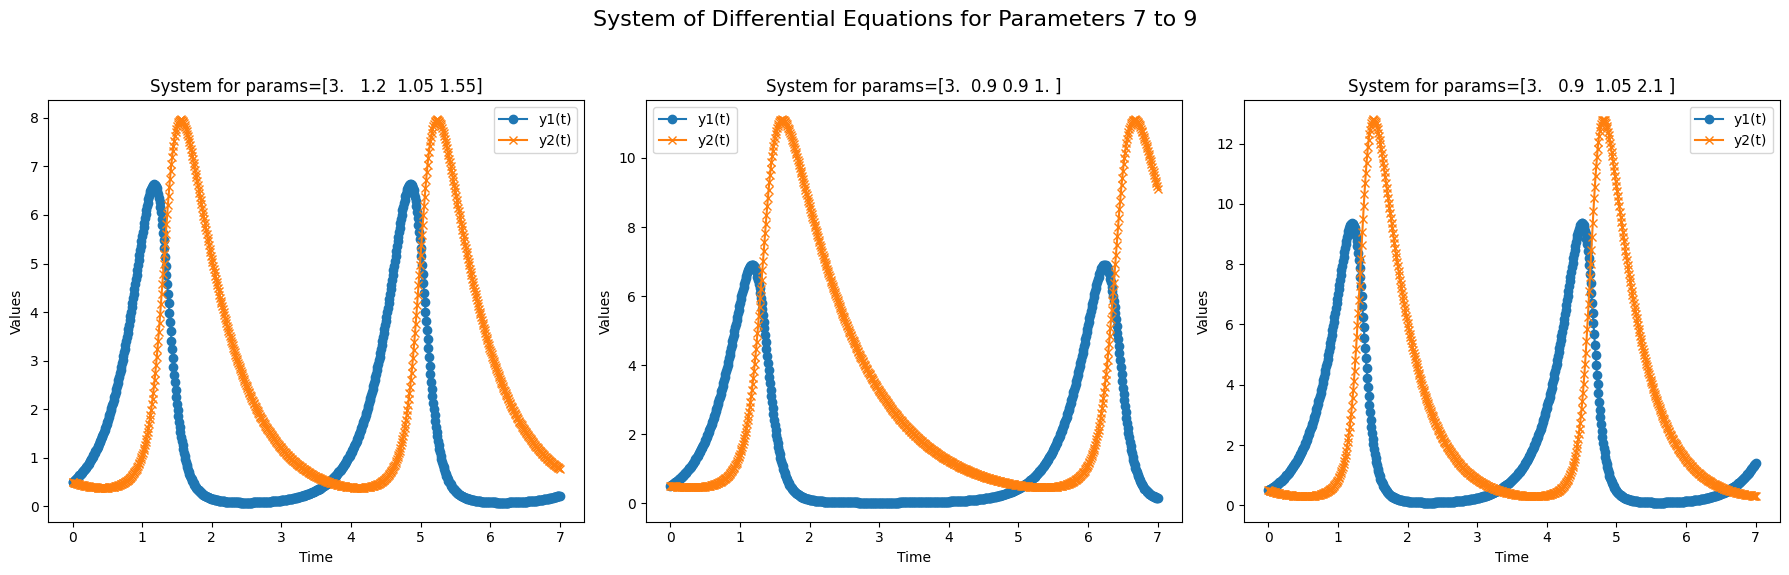

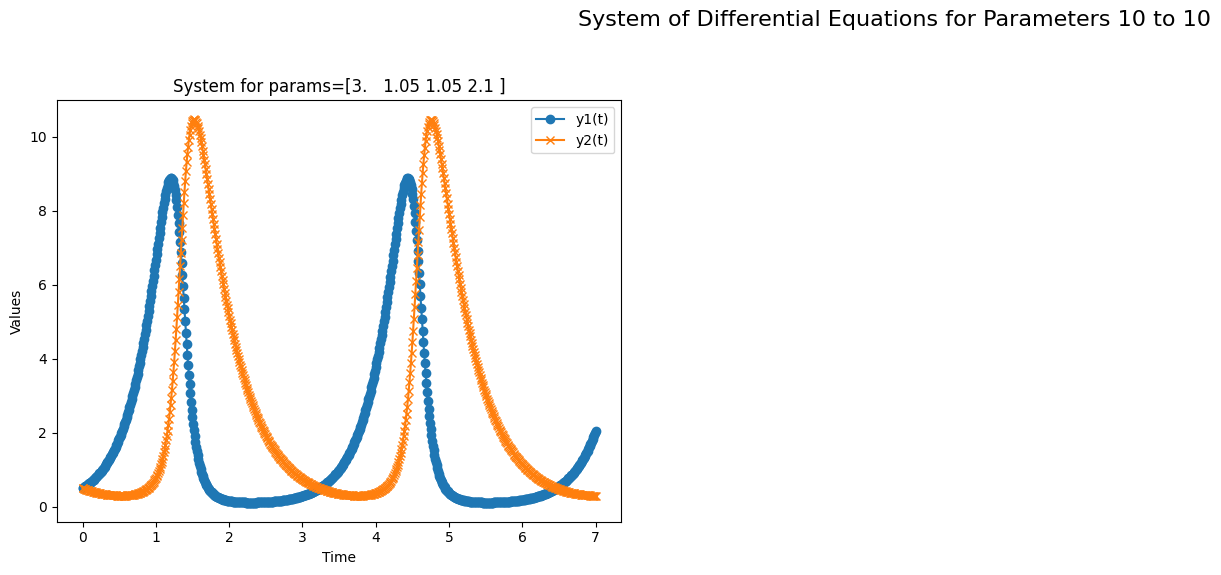

In [6]:
solver_HF.plot_results()

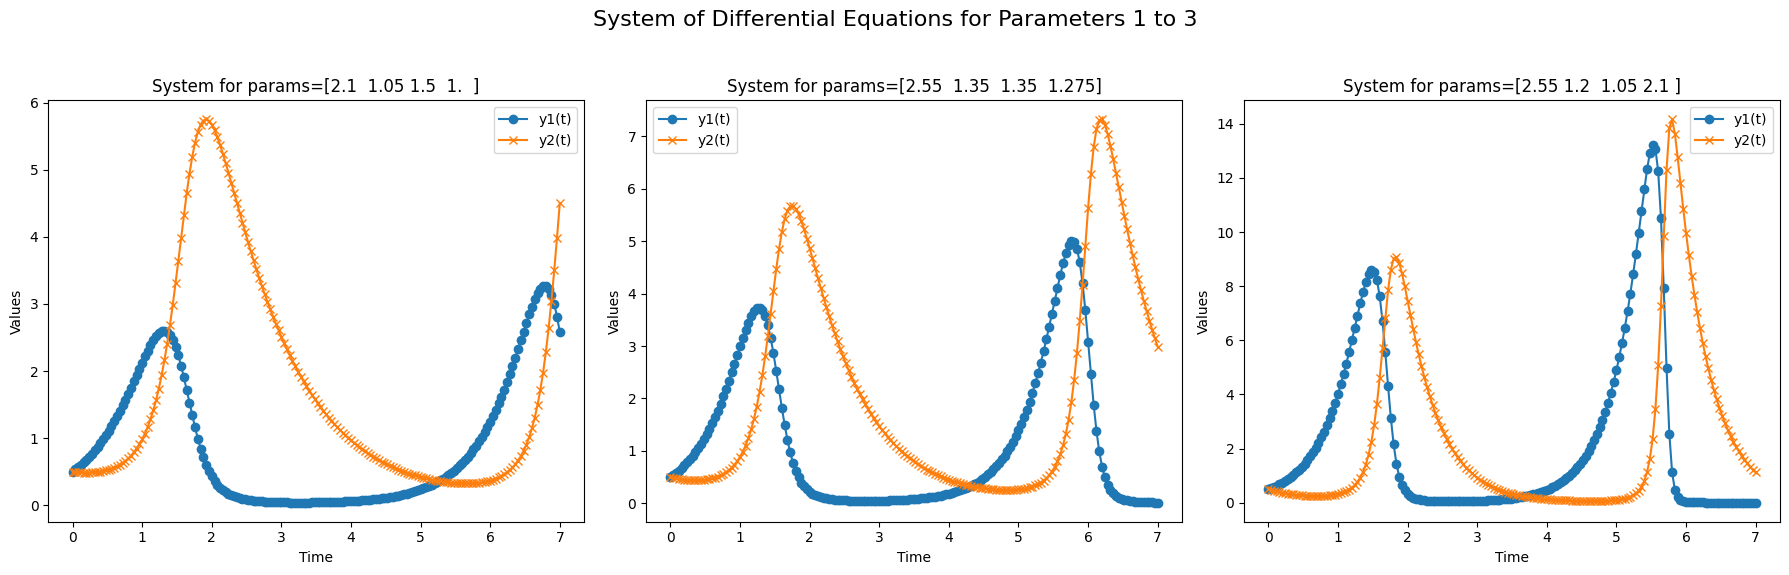

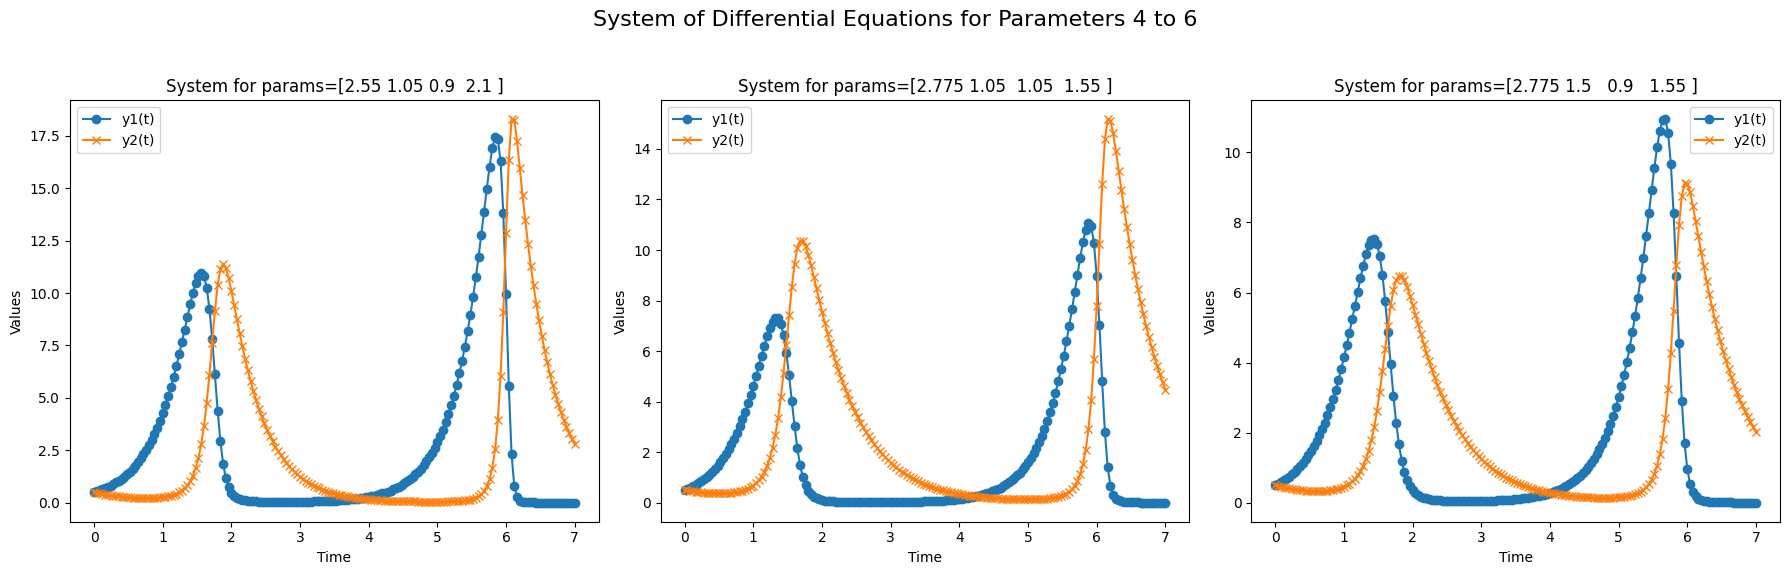

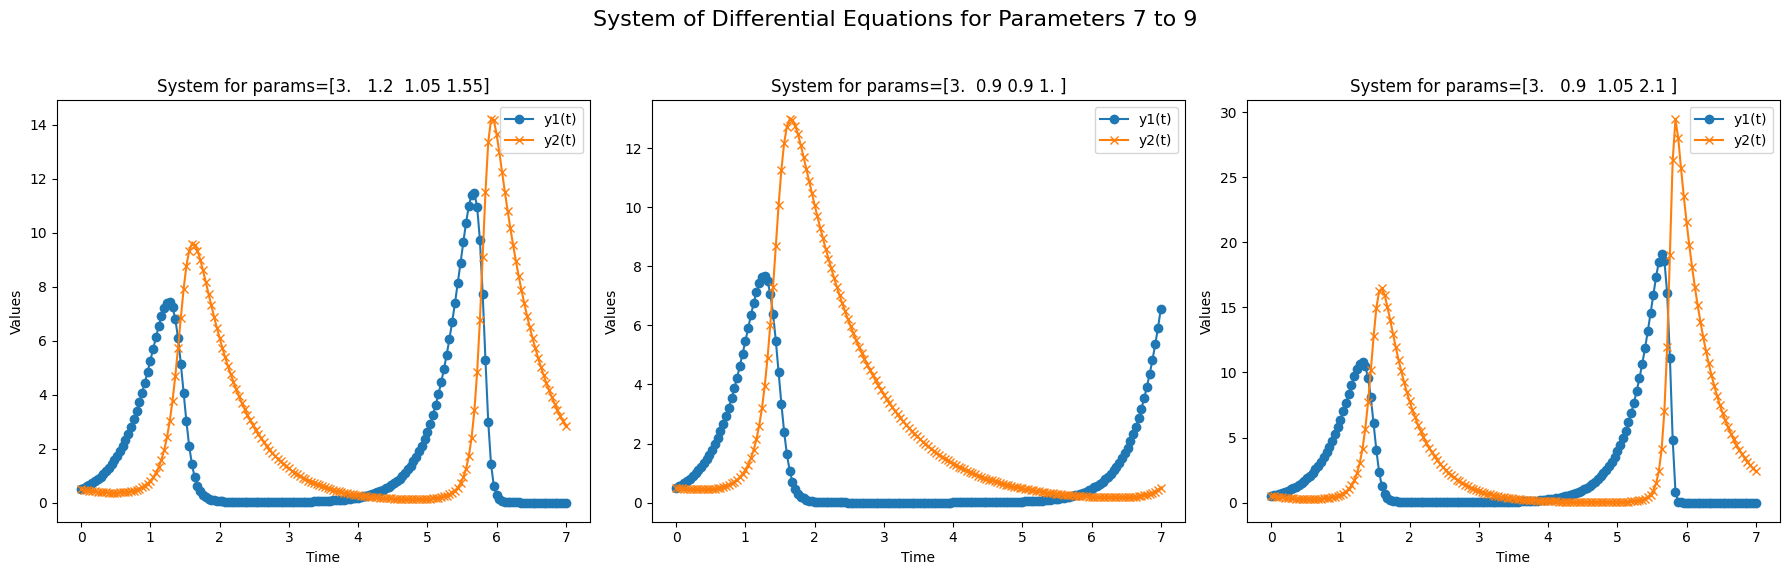

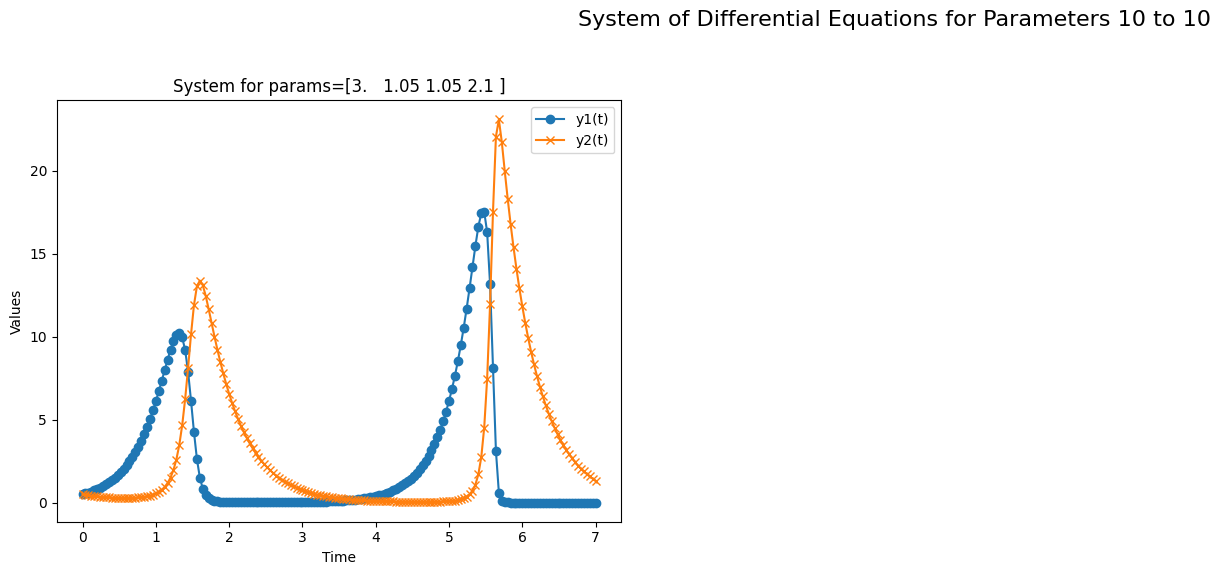

In [7]:
solver_LF.plot_results()

In [8]:
# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_HF.shape[0]), np.arange(t_HF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_HF = np.hstack((t_HF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_HF[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_LF.shape[0]), np.arange(t_LF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_LF = np.hstack((t_LF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_LF[cartesian_product_indices[:, 0]]))


In [9]:
x_LF.shape

(1760, 5)

In [10]:
y_HF=np.array(y_HF).reshape(-1, solver_HF.get_dim())
y_LF=np.array(y_LF).reshape(-1, solver_LF.get_dim())

In [11]:
y_HF.shape

(7010, 2)

In [12]:
x_HF.shape

(7010, 5)

HPO name: LF


[I 2024-08-17 03:30:07,573] A new study created in RDB with name: no-name-28263308-4cb7-4915-ab1f-28e92b1bd65e
[I 2024-08-17 03:31:58,525] Trial 0 finished with value: 1.3695297707482315 and parameters: {'nodes': 38, 'l2weight': 0.05551593317030337, 'lr': 0.026436874619906264, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 1.3695297707482315.
[I 2024-08-17 03:31:59,377] Trial 4 finished with value: 8.675275403048122 and parameters: {'nodes': 5, 'l2weight': 0.006225595928782283, 'lr': 0.00023092017901003397, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 1.3695297707482315.
[I 2024-08-17 03:31:59,415] Trial 2 finished with value: 2.7298231814013456 and parameters: {'nodes': 58, 'l2weight': 0.07827282555279255, 'lr': 0.004842601045092952, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 0 with value: 1.3695297707482315.
[I 2024-08-17 03:31:59,429] Trial 3 finished with value: 2.481527676564063 and parameters: {'nodes'

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.009439001042229658,
 'lr': 0.001547841664661148,
 'nodes': 8,
 'opt': 'Adam'}
The function training took 42.169411 seconds.


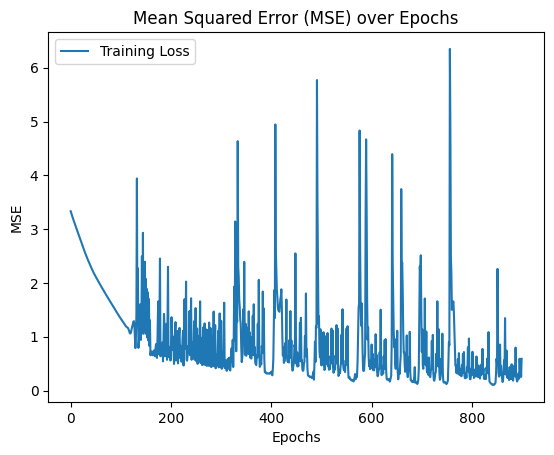

[I 2024-08-17 03:35:22,575] A new study created in RDB with name: no-name-8a4ddae7-61f6-4a7e-a64f-4dfb8cbff9b3


HPO name: Single


[I 2024-08-17 03:36:08,390] Trial 1 finished with value: 0.11210170177205017 and parameters: {'nodes': 5, 'l2weight': 0.000258392824624208, 'lr': 0.014543316764914976, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 1 with value: 0.11210170177205017.
[I 2024-08-17 03:36:09,189] Trial 8 finished with value: 1.0246620930818742 and parameters: {'nodes': 24, 'l2weight': 0.0006727300874592925, 'lr': 0.0019701905451102366, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.11210170177205017.
[I 2024-08-17 03:36:09,206] Trial 4 finished with value: 0.7023109441539268 and parameters: {'nodes': 4, 'l2weight': 0.003195062517835717, 'lr': 0.00242175518151342, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.11210170177205017.
[I 2024-08-17 03:36:09,324] Trial 3 finished with value: 1.9536842721611947 and parameters: {'nodes': 9, 'l2weight': 0.019212590318378332, 'lr': 0.0010474880043141559, 'kernel_init': 'uniform', 'opt': 'Adamax'}. 

New parameters identified during HPO:
{'kernel_init': 'uniform',
 'l2weight': 0.000258392824624208,
 'lr': 0.014543316764914976,
 'nodes': 5,
 'opt': 'Adam'}
The function training took 15.659353 seconds.


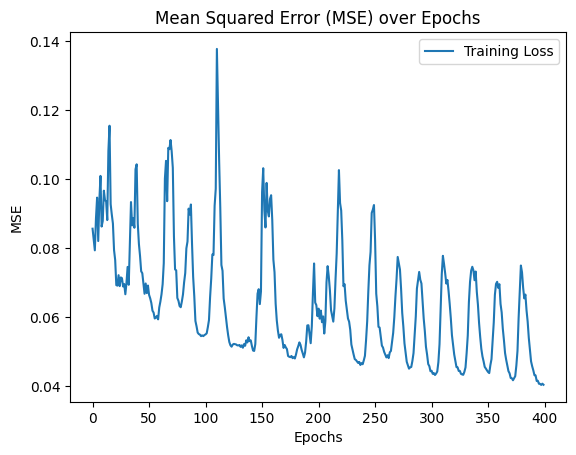

[I 2024-08-17 03:37:37,347] A new study created in RDB with name: no-name-47e53a67-f4c7-4baf-96c9-d92927aaedf9


HPO name: HF


[I 2024-08-17 03:38:49,094] Trial 1 finished with value: 5.478112720426351 and parameters: {'nodes': 9, 'l2weight': 0.0053365017837348535, 'lr': 0.0001108687115318113, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 5.478112720426351.
[I 2024-08-17 03:38:53,211] Trial 4 finished with value: 0.11141565656375493 and parameters: {'nodes': 8, 'l2weight': 0.0001437386501224676, 'lr': 0.001938948808460622, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 4 with value: 0.11141565656375493.
[I 2024-08-17 03:38:54,212] Trial 6 finished with value: 0.02183134144123228 and parameters: {'nodes': 5, 'l2weight': 0.009647723430978146, 'lr': 0.04543981494762212, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 6 with value: 0.02183134144123228.
[I 2024-08-17 03:38:54,933] Trial 7 finished with value: 0.05184619562538254 and parameters: {'nodes': 6, 'l2weight': 0.00012035213282715934, 'lr': 0.03921342685623613, 'kernel_init': 'glorot_uniform', 'opt': 'Adam

New parameters identified during HPO:
{'kernel_init': 'uniform',
 'l2weight': 0.00021648620511098636,
 'lr': 0.023156568390181882,
 'nodes': 8,
 'opt': 'Adam'}
The function training took 30.040109 seconds.


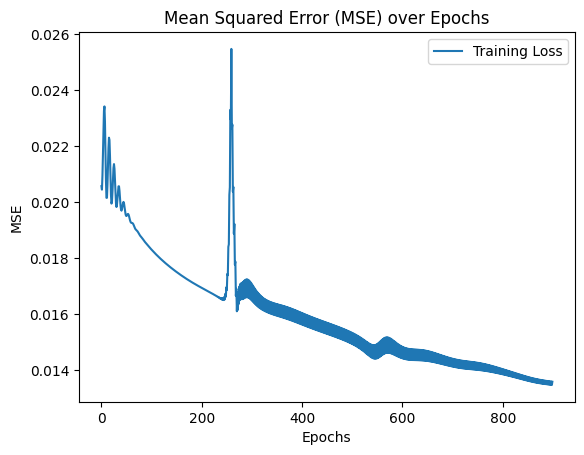

Test MSE: 0.16348023435204087
R^2: 0.9634880386961828


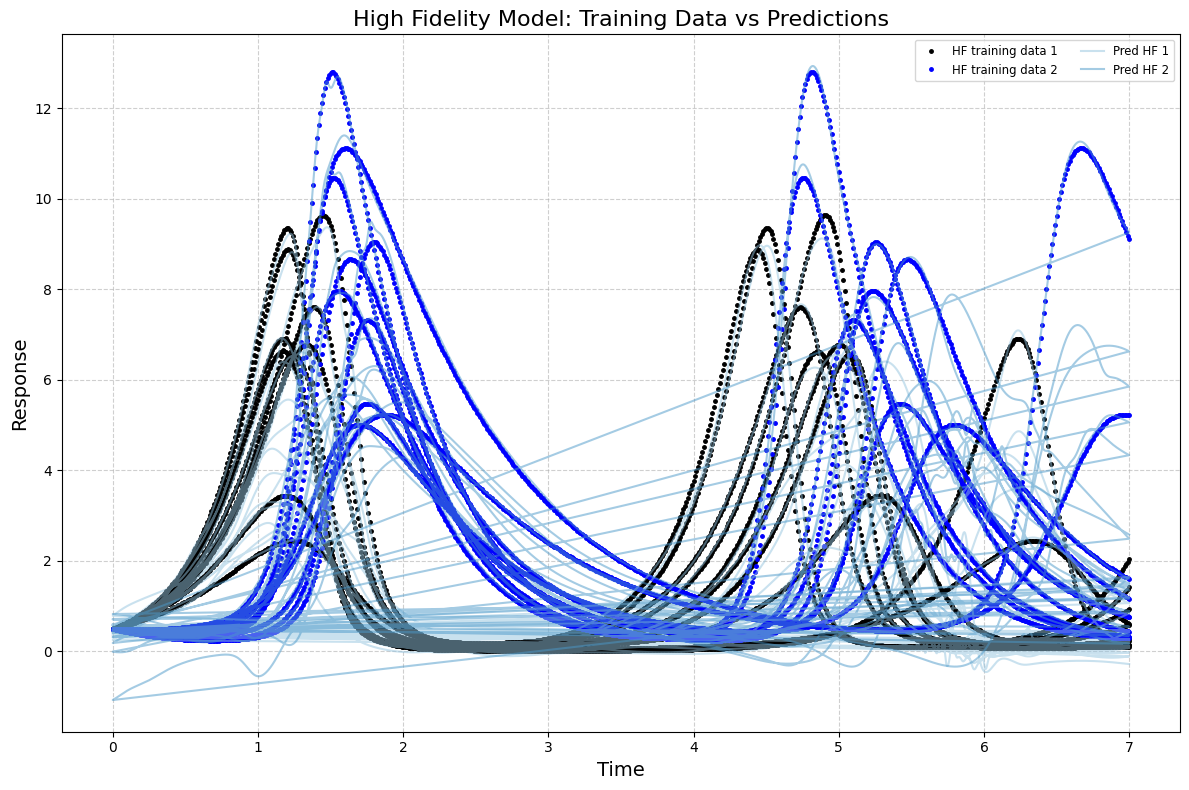

In [13]:
n_LF=700
indices_LF = np.random.permutation(x_LF.shape[0])[:n_LF]

n_Single=1500
indices_Single = np.random.permutation(x_HF.shape[0])[:n_Single]

n_HF=2000
indices_HF = np.random.permutation(x_HF.shape[0])[:n_HF]

N=[1000,500,1000]
#n=[500,1000]
n=[75,150,200]

names = ['LF','Single', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params_single={'kernel_init': 'uniform', 
             'l2weight': 0.005395541657336886, 
             'lr': 0.0025412188591473228,  
             'opt': 'Adamax'}

best_params={'kernel_init': 'uniform', 
             'l2weight': 0.005395541657336886, 
             'lr': 0.0025412188591473228, 
             'nodes': 12.0, 
             'opt': 'Adamax'}

params_NN=[bestLF_params,best_params_single, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "3step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF[indices_LF,:],x_HF[indices_Single,:],x_HF[indices_HF,:]],
    "output_train": [y_LF[indices_LF,:],  y_HF[indices_Single,:],y_HF[indices_HF,:]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=7.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


plt.figure(figsize=(12, 8))

# Plotting the training data with darker markers
plt.plot(x_HF[:, 0], y_HF[:, 0], 'k.', label='HF training data 1', markersize=5)  # Nero
plt.plot(x_HF[:, 0], y_HF[:, 1], 'b.', label='HF training data 2', markersize=5)  # Blu scuro

# Plotting the prediction data with lighter, less fluorescent colors
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '-', 
             color=plt.cm.Blues(0.4 + 0.4 * i / y_test_pred.shape[1]),  # Gamma di blu meno vividi
             alpha=0.5, label=f'Pred HF {i+1}', linewidth=1.5)  # Trasparenza ridotta e linee più sottili

# Adding grid to the plot
plt.grid(True, linestyle='--', alpha=0.6)

# Adding labels to the axes
plt.xlabel('Time', fontsize=14)
plt.ylabel('Response', fontsize=14)

# Enhancing the title
plt.title('High Fidelity Model: Training Data vs Predictions', fontsize=16)

# Improving the legend
plt.legend(loc='best', fontsize='small', ncol=2)

# Adjusting the layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

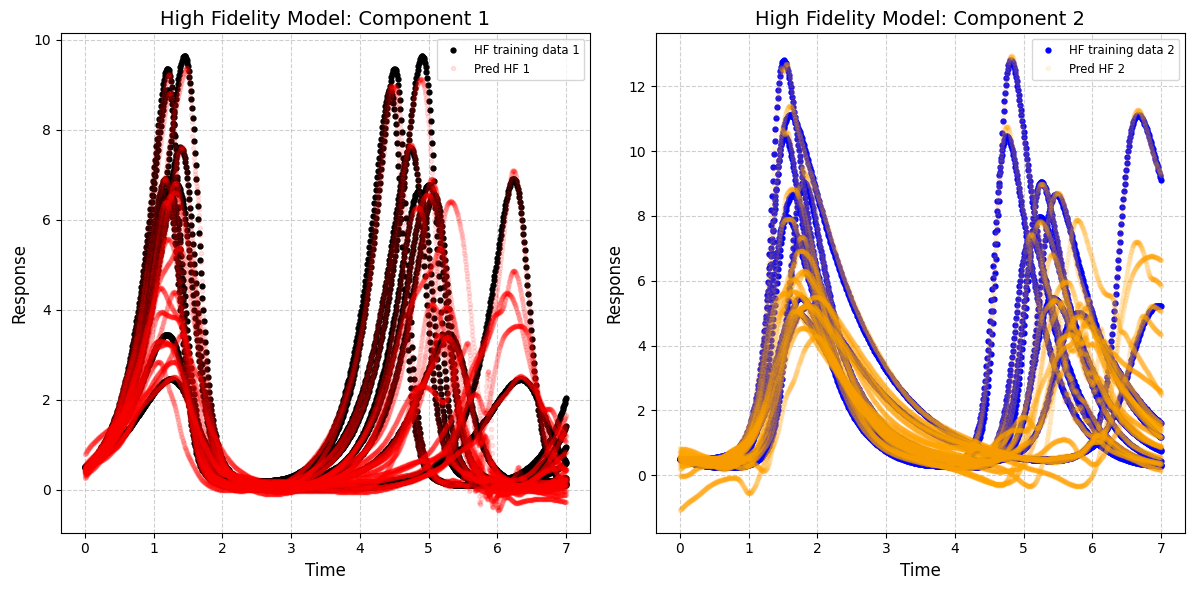

In [16]:
components = ['Component 1', 'Component 2']
colors_training = ['k', 'b', 'g']  # Nero, Blu scuro, Verde scuro
colors_pred = ['r', 'orange', 'purple']  # Rosso, Arancione, Viola

plt.figure(figsize=(18, 6))

# Loop through each component to create a separate plot
for i in range(2):
    plt.subplot(1, 3, i + 1)  # Create a subplot (1 row, 3 columns)
    
    # Plotting the training data for the i-th component
    plt.plot(x_HF[:, 0], y_HF[:, i], f'{colors_training[i]}.', label=f'HF training data {i + 1}', markersize=7)

    # Plotting the prediction data for the i-th component
    plt.plot(datatest[:, 0], y_test_pred[:, i], '.', 
             color=colors_pred[i], alpha=0.1, label=f'Pred HF {i + 1}', linewidth=3)
    
    # Adding grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title(f'High Fidelity Model: {components[i]}', fontsize=14)
    
    # Add a legend
    plt.legend(loc='best', fontsize='small')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

In [17]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 30
burnin = 20
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)


TypeError: 'Posterior' object is not subscriptable